In [2]:
import numpy as np
import torch
import time
import os
import csv

from datasets import load_dataset, concatenate_datasets
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    TrainerCallback,
    EarlyStoppingCallback
)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val= load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test= load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")
print(train)  # Print the first example to understand its structure

train_df = train.to_pandas()
print("Sample data (first 5 rows):")
print(train_df.head())

full_data = concatenate_datasets([train, val, test])

# Total size
len_total = len(full_data)

# Exact 70/20/10 counts
target_train= int(round(0.70 * len_total))
target_val   = int(round(0.20 * len_total))
target_test  = len_total - target_train - target_val

split_1 = full_data.train_test_split(train_size=target_train, seed=42)
train_data = split_1["train"]
remaining  = split_1["test"]

# Split remaining into val and test
split_2 = remaining.train_test_split(train_size=target_val, seed=42)
val_data  = split_2["train"]
test_data = split_2["test"]

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))



Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

eng/train-00000-of-00001.parquet:   0%|          | 0.00/179k [00:00<?, ?B/s]

eng/dev-00000-of-00001.parquet:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

eng/test-00000-of-00001.parquet:   0%|          | 0.00/182k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2763 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/115 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2765 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'text', 'anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise'],
    num_rows: 2763
})
Sample data (first 5 rows):
                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  disgust  fear  joy  sadness  surprise  
0      0      NaN     1    0        0         1  
1      0      NaN     2    0        0         0  
2      0      NaN     1    0        3         0  
3      0      NaN     0    0        0         0  
4      0      NaN     3    0        1         2  
Train size: 3950
Validation size: 1129
Test size: 564


In [4]:
TEXT_COL = "text"

EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]

tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess(example):
    encoded = tokenizer(
        example[TEXT_COL],
        truncation=True,
        max_length=256,
    )
    encoded["labels"] = [
        [float(example[e]) for e in EMOTIONS]
    ]
    return encoded

train_tok = train_data.map(preprocess)
val_tok   = val_data.map(preprocess)
test_tok  = test_data.map(preprocess)

cols = ["input_ids", "attention_mask", "labels"]
train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1129 [00:00<?, ? examples/s]

Map:   0%|          | 0/564 [00:00<?, ? examples/s]

In [5]:
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(EMOTIONS),
    problem_type="regression"
).to(device)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
def safe_pearson(x, y):
    r, _ = pearsonr(x, y)
    return 0.0 if np.isnan(r) else float(r)

def compute_metrics(eval_pred):
    preds = eval_pred.predictions
    labels = eval_pred.label_ids

    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.asarray(preds)
    labels = np.asarray(labels)

    print("preds shape:", preds.shape)
    print("labels shape:", labels.shape)

    if preds.ndim == 3:
        preds = preds.squeeze(1)

    if labels.ndim == 3:
        labels = labels.squeeze(1)

    metrics = {}
    rs = []

    for i, emo in enumerate(EMOTIONS):
        pred_col = preds[:, i]
        label_col = labels[:, i]

        r = safe_pearson(pred_col, label_col)
        metrics[f"pearson_{emo}"] = r
        rs.append(r)

    metrics["pearson_mean"] = float(np.mean(rs))
    return metrics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Si

Epoch,Training Loss,Validation Loss,Pearson Anger,Pearson Fear,Pearson Joy,Pearson Sadness,Pearson Surprise,Pearson Mean
1,0.596428,0.591776,-0.004551,0.039327,0.065632,0.000753,0.071884,0.034609
2,0.589400,0.589164,-0.010476,0.058630,0.042267,-0.023200,0.003615,0.014167
3,0.586162,0.592728,-0.013445,0.045199,0.067654,0.023406,0.102675,0.045098
4,0.585927,0.580801,0.002144,0.046279,0.070081,0.024050,0.056960,0.039903
5,0.584383,0.584310,0.008562,0.051951,0.060344,-0.014346,-0.030972,0.015108
6,0.584427,0.584938,-0.003744,-0.095189,0.047911,0.072577,-0.072035,-0.010096
7,0.583288,0.582462,-0.008687,0.026855,0.044340,0.019475,-0.029386,0.010519
8,0.582638,0.583381,0.042799,0.037956,0.030325,0.010531,-0.022601,0.019802
9,0.582035,0.581822,0.025528,0.052755,0.018215,-0.010526,-0.028805,0.011434
10,0.581981,0.581716,-0.016735,0.017623,0.061511,0.001728,-0.058754,0.001075


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([6, 1, 5])) that is different to the input size (torch.Size([6, 5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([4, 1, 5])) that is different to the input size (torch.Size([4, 5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1, 5])) that is different to the input size (torch.Size([1, 5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse

preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)


/tmp/ipykernel_7182/2153589096.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(x, y)


preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)
preds shape: (1129, 5)
labels shape: (1129, 1, 5)


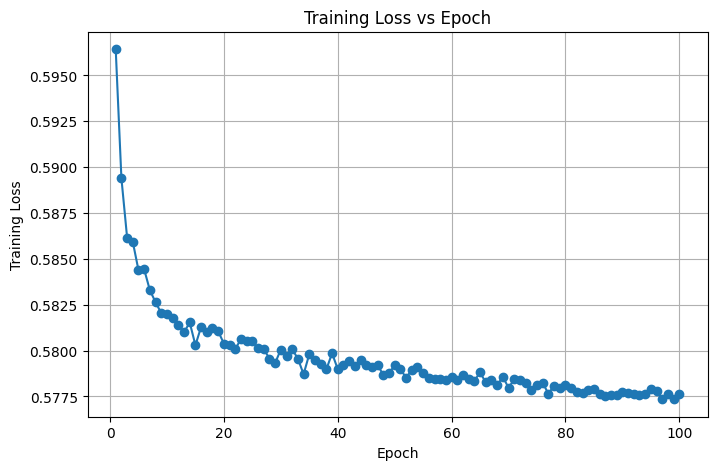

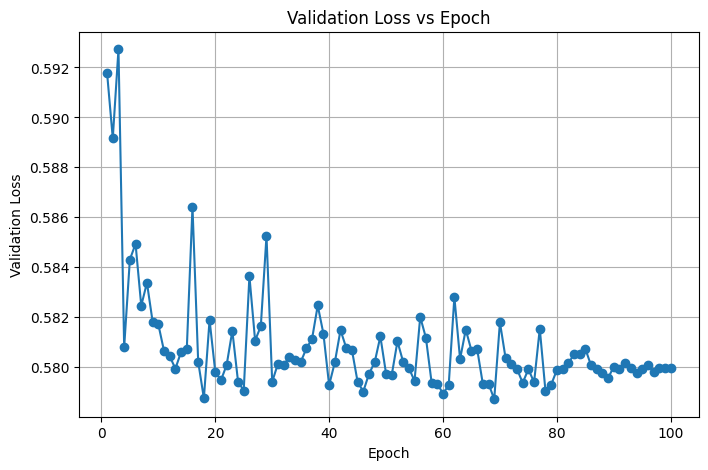

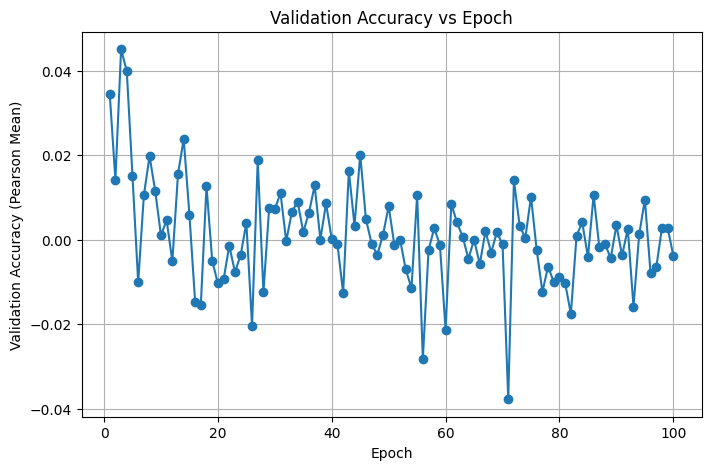

In [10]:
from google.colab import drive
drive.mount('/content/drive')


LOG_FILE = "/content/drive/MyDrive/RoBERTa_Log.csv"
os.makedirs("/content/drive/MyDrive", exist_ok=True)

# Create CSV file
with open(LOG_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "eval_loss",
        "pearson_mean",
        "pearson_anger",
        "pearson_fear",
        "pearson_joy",
        "pearson_sadness",
        "pearson_surprise"
    ])

# Lists for plotting
epoch_list = []
train_loss_list = []
eval_loss_list = []
accuracy_list = []

class SaveMetricsCallback(TrainerCallback):
    def __init__(self, file_path):
        self.file_path = file_path
        self.current_train_loss = None

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is not None:
            epoch = int(metrics.get("epoch", state.epoch))
            train_loss = self.current_train_loss if self.current_train_loss is not None else ""
            eval_loss = float(metrics.get("eval_loss", 0.0))
            accuracy = float(metrics.get("eval_pearson_mean", 0.0))

            pearson_anger = float(metrics.get("eval_pearson_anger", 0.0))
            pearson_fear = float(metrics.get("eval_pearson_fear", 0.0))
            pearson_joy = float(metrics.get("eval_pearson_joy", 0.0))
            pearson_sadness = float(metrics.get("eval_pearson_sadness", 0.0))
            pearson_surprise = float(metrics.get("eval_pearson_surprise", 0.0))

            epoch_list.append(epoch)
            train_loss_list.append(train_loss)
            eval_loss_list.append(eval_loss)
            accuracy_list.append(accuracy)

            with open(self.file_path, "a", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    epoch,
                    train_loss,
                    eval_loss,
                    accuracy,
                    pearson_anger,
                    pearson_fear,
                    pearson_joy,
                    pearson_sadness,
                    pearson_surprise
                ])

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(EMOTIONS),
    problem_type="regression"
).to(device)

training_args = TrainingArguments(
    output_dir="/content/roberta_output_60",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    num_train_epochs=100,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[SaveMetricsCallback(LOG_FILE)],
)

start = time.time()
trainer.train()
end = time.time()

print(f"Total training time: {end - start:.1f} seconds")
print(f"Average time per epoch: {(end - start) / 60:.1f} seconds")
print("Log file saved at:", LOG_FILE)

# Graph 1: Training Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, train_loss_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.show()

# Graph 2: Validation Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, eval_loss_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
plt.grid(True)
plt.show()

# Graph 3: Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, accuracy_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (Pearson Mean)")
plt.title("Validation Accuracy vs Epoch")
plt.grid(True)
plt.show()

In [ ]:
test_results = trainer.evaluate(test_tok)
print("Test results:", test_results)

In [ ]:
def predict_intensities(text: str):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits.detach().cpu().numpy()[0]

    discrete = np.clip(np.rint(logits), 0, 3).astype(int)

    return {
        EMOTIONS[i]: {
            "raw": float(logits[i]),
            "intensity_0_3": int(discrete[i])
        }
        for i in range(len(EMOTIONS))
    }

print(predict_intensities("I feel so happy and joyful today!"))